
# EN.605.631 — Probability Foundations with R (Chapter 2)

**Submission format:** Jupyter Notebook (`.ipynb`) using the **R kernel**  
**Estimated time:** ~5 hours  
**Total points:** 100

---

## Instructions
- Work directly in this notebook. For each problem, add your derivations/explanations in Markdown and write your **R code** in the empty code cell(s) below each prompt.
- At the very top, include your environment information and set a fixed seed.
- Your notebook must run top-to-bottom with **Restart & Run All** in under 2 minutes.
- File name on submission: `lastname_firstname_ch2_axioms.ipynb`.

## Required setup (fill in below)
- Show `R.version.string` and `sessionInfo()`
- Set a seed: `set.seed(631)`
- List any additional packages used (base R preferred)


In [1]:
R.version.string

[1] "R version 4.6.1 (2026-06-24 ucrt)"

In [2]:
sessionInfo()

R version 4.6.1 (2026-06-24 ucrt)
Platform: x86_64-w64-mingw32/x64
Running under: Windows 11 x64 (build 26200)

Matrix products: default
  LAPACK version 3.12.1

locale:
[1] LC_COLLATE=English_United States.utf8 
[2] LC_CTYPE=English_United States.utf8   
[3] LC_MONETARY=English_United States.utf8
[4] LC_NUMERIC=C                          
[5] LC_TIME=English_United States.utf8    

time zone: America/New_York
tzcode source: internal

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

loaded via a namespace (and not attached):
 [1] digest_0.6.39     IRdisplay_1.1     base64enc_0.1-6   fastmap_1.2.0    
 [5] glue_1.8.1        htmltools_0.5.9   repr_1.1.7        lifecycle_1.0.5  
 [9] cli_3.6.6         vctrs_0.7.3       textshaping_1.0.5 pbdZMQ_0.3-14    
[13] systemfonts_1.3.2 compiler_4.6.1    tools_4.6.1       ragg_1.5.2       
[17] evaluate_1.0.5    pillar_1.11.1     rlang_1.3.0       jsonlite_2.0.0   
[21] crayon_1.5.3      IRkernel_1.

In [3]:
set.seed(631)


---
## Problem 1 — Sample spaces, events, and set algebra (10 pts)

Construct a finite sample space for “toss two fair coins and roll one fair die” with outcomes `(c1, c2, d)`. Represent events as logical vectors or index sets.

1. Define events:  
   - **E**: “at least one head”  
   - **F**: “die shows an odd number”  
   - **G**: “exactly one head and die shows 5”

2. Implement helpers `ev_union(E,F)`, `ev_intersect(E,F)`, `ev_comp(E)` and **verify** De Morgan’s laws and distributive laws numerically (every outcome satisfies the identity).

3. Compute probabilities by enumeration (equally likely outcomes) and confirm:  
   \(P(E\cup F)=P(E)+P(F)-P(EF)\).


### Sample Space

In [4]:
S <- expand.grid(
    c1 = c("H", "T"),
    c2 = c("H", "T"),
    d  = 1:6
)
S$outcome <- paste0(S$c1, S$c2, S$d)
S

c1,c2,d,outcome
<fct>,<fct>,<int>,<chr>
H,H,1,HH1
T,H,1,TH1
H,T,1,HT1
T,T,1,TT1
H,H,2,HH2
T,H,2,TH2
H,T,2,HT2
T,T,2,TT2
H,H,3,HH3


### Events

In [5]:
E <- which(S$c1 == "H" | S$c2 == "H")
E
S$outcome[E]

[1]  1  2  3  5  6  7  9 10 11 13 14 15 17 18 19 21 22 23

[1] "HH1" "TH1" "HT1" "HH2" "TH2" "HT2" "HH3" "TH3" "HT3" "HH4" "TH4" "HT4"
[13] "HH5" "TH5" "HT5" "HH6" "TH6" "HT6"

In [6]:
F <- which(S$d %% 2 == 1)
F
S$outcome[F]

[1]  1  2  3  4  9 10 11 12 17 18 19 20

[1] "HH1" "TH1" "HT1" "TT1" "HH3" "TH3" "HT3" "TT3" "HH5" "TH5" "HT5" "TT5"

In [7]:
G <- which((xor(S$c1 == "H", S$c2 == "H")) & (S$d == 5))
G
S$outcome[G]

[1] 18 19

[1] "TH5" "HT5"

### Helper Utilities

In [8]:
ev_union <- function(E, F) {
    return(sort(union(E, F)))
}

In [9]:
ev_union(c(1, 3, 5), c(2, 3, 5))
ev_union(c(1, 3, 5), c(1, 3, 5))
ev_union(c(1, 3, 5), c(2, 4, 6))

[1] 1 2 3 5

[1] 1 3 5

[1] 1 2 3 4 5 6

In [10]:
ev_intersect <- function(E, F) {
    return(sort(intersect(E, F)))
}

In [11]:
ev_intersect(c(1, 3, 5), c(2, 3, 5))
ev_intersect(c(1, 3, 5), c(1, 3, 5))
ev_intersect(c(1, 3, 5), c(2, 4, 6))

[1] 3 5

[1] 1 3 5

numeric(0)

In [12]:
ev_comp <- function(E) {
    return(setdiff(1:24, E))
}

In [13]:
ev_comp(c(1, 3, 5))
ev_comp(c(2, 3, 5))
ev_comp(c(2, 4, 6))

[1]  2  4  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24

[1]  1  4  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24

[1]  1  3  5  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24

### Verifying Laws

DeMorgan's Law 1:
$(E \cup F)^c = E^c \cap F^c$

In [14]:
ev_comp(ev_union(E, F))
ev_intersect(ev_comp(E), ev_comp(F))

[1]  8 16 24

[1]  8 16 24

DeMorgan's Law 1: $(E \cap F)^c = E^c \cup F^c$

In [15]:
ev_comp(ev_intersect(E, F))
ev_union(ev_comp(E), ev_comp(F))

[1]  4  5  6  7  8 12 13 14 15 16 20 21 22 23 24

[1]  4  5  6  7  8 12 13 14 15 16 20 21 22 23 24

Distributive Law 1: $E \cap (F \cup G) = (E \cap F) \cup (E \cap G)$

In [16]:
ev_intersect(E, ev_union(F, G))
ev_union(ev_intersect(E, F), ev_intersect(E, G))

[1]  1  2  3  9 10 11 17 18 19

[1]  1  2  3  9 10 11 17 18 19

Distributive Law 1: $E \cup (F \cap G) = (E \cup F) \cap (E \cup G)$

In [17]:
ev_union(E, ev_intersect(F, G))
ev_intersect(ev_union(E, F), ev_union(E, G))

[1]  1  2  3  5  6  7  9 10 11 13 14 15 17 18 19 21 22 23

[1]  1  2  3  5  6  7  9 10 11 13 14 15 17 18 19 21 22 23

### Confirm Inclusion Exclusion

$(P(E\cup F)=P(E)+P(F)-P(EF))$

In [18]:
prob <- function(A, n) {
    length(A) / n
}
n <- nrow(S)

PEUF = prob(ev_union(E, F), n)
PE <- prob(E, n)
PF <- prob(F, n)
PEF <- prob(ev_intersect(E, F), n)

PEUF
PE + PF - PEF

[1] 0.875

[1] 0.875


---
## Problem 2 — Axioms and finite additivity (12 pts)

Let the sample space be two distinguishable fair dice.

1. Define events $(A_k = \{\text{sum}=k\})$ for $(k=2,\dots,12)$. Verify $(\sum_k P(A_k)=1)$ and $(0\le P(A_k)\le1)$.  
2. Randomly generate \(M=50\) families of **pairwise disjoint** events (e.g., disjoint rectangles of outcomes) and verify finite additivity $(P(\bigcup_i B_i)=\sum_i P(B_i))$ by enumeration. Report the maximum absolute discrepancy.


### Sample Space

In [19]:
S <- expand.grid(
    d1 = 1:6,
    d2 = 1:6
)
S$sum <- S$d1 + S$d2
S

d1,d2,sum
<int>,<int>,<int>
1,1,2
2,1,3
3,1,4
4,1,5
5,1,6
6,1,7
1,2,3
2,2,4
3,2,5


### Events 

$(A_k = \{\text{sum}=k\})$ for $(k=2,\dots,12)$

In [20]:
k_vec <- 2:12
n <- nrow(S)
counts <- sapply(k_vec, function(k) sum(S$sum == k))
probs <- counts / n

### Verify Axiom

$(\sum_k P(A_k)=1)$

In [21]:
sum(probs)

[1] 1

### Verify Axiom

$(0\le P(A_k)\le1)$

In [22]:
probs

[1] 0.02777778 0.05555556 0.08333333 0.11111111 0.13888889 0.16666667
 [7] 0.13888889 0.11111111 0.08333333 0.05555556 0.02777778

### (M=50) Pairwise Disjoint Events

In [23]:
Bs <- vector("list", 50)
for (m in 1:50) {
    # assign each outcome in S to an event (up to 4 events) in B
    r <- sample(2:4, 1)
    labels <- sample(1:r, 36, replace = TRUE)
    Bs[[m]] <- lapply(1:r, function(i) which(labels == i))
}

### Verify finite additivity 

$(P(\bigcup_i B_i)=\sum_i P(B_i))$ by enumeration

In [24]:
max_discrepancy <- 0
for (m in 1:50) {
    B <- Bs[[m]]

    prob_union <- length(unique(unlist(B))) / 36
    prob_sum <- sum(sapply(B, length) / 36)
    
    print(prob_union == prob_sum)
    max_discrepancy <- max(c(max_discrepancy, abs(prob_union - prob_sum)))
}

[1] TRUE
[1] TRUE
[1] TRUE
[1] TRUE
[1] TRUE
[1] TRUE
[1] TRUE
[1] TRUE
[1] TRUE
[1] TRUE
[1] TRUE
[1] TRUE
[1] TRUE
[1] TRUE
[1] TRUE
[1] TRUE
[1] TRUE
[1] TRUE
[1] TRUE
[1] TRUE
[1] TRUE
[1] TRUE
[1] TRUE
[1] TRUE
[1] TRUE
[1] TRUE
[1] TRUE
[1] TRUE
[1] TRUE
[1] TRUE
[1] TRUE
[1] TRUE
[1] TRUE
[1] TRUE
[1] TRUE
[1] TRUE
[1] TRUE
[1] TRUE
[1] TRUE
[1] TRUE
[1] TRUE
[1] TRUE
[1] TRUE
[1] TRUE
[1] TRUE
[1] TRUE
[1] TRUE
[1] TRUE
[1] TRUE
[1] TRUE


Maximum absolute discrepancy:

In [25]:
max_discrepancy

[1] 0


---
## Problem 3 — Inclusion–exclusion and Boole’s inequality (14 pts)

Consider dealing a 5-card hand from a standard 52-card deck.

1. Define events: **E** = “at least one Ace”, **F** = “at least one King”, **G** = “at least one Queen”.  
   - Compute $\(P(E\cup F\cup G)\)$ **exactly** via inclusion–exclusion (use combinations).  
   - Cross-check with a Monte Carlo simulation (≥ 200,000 hands); report absolute error.

2. Using your exact components, verify **Boole’s inequality**: $\(P(E\cup F\cup G)\le P(E)+P(F)+P(G)\)$.

3. Generalize: write `px_union_upper(A_list)` that returns $\(\sum_i P(A_i)\)$ and `px_union_ie(A_list)` that returns the full inclusion–exclusion for a small list of events. Demonstrate on 4 events over a 16-point synthetic space.


By inclusion-exclusion: $$P(E\cup F\cup G) = P(E)+P(F)+P(G) - P(E\cap F) - P(E\cap G) - P(F\cap G) + P(E\cap F\cap G)$$

$$P(E)=1-P(E^c)$$

$$P(E^c)=\frac{\binom{48}{5}}{\binom{52}{5}}$$

$$P(E)=P(F)=P(G)=1-\frac{\binom{48}{5}}{\binom{52}{5}}$$

In [26]:
PE <- 1 - choose(48, 5) / choose(52, 5)
PF <- 1 - choose(48, 5) / choose(52, 5)
PG <- 1 - choose(48, 5) / choose(52, 5)

$$P(E\cap F)=1-P(E^c\cup F^c)$$

By inclusion–exclusion:

$$P(E^c\cup F^c)=P(E^c)+P(F^c)-P(E^c\cap F^c)$$

$$P(E\cap F)=1-P(E^c)-P(F^c)+P(E^c\cap F^c)$$

$$P(E^c)=P(F^c)=\frac{\binom{48}{5}}{\binom{52}{5}}$$

$$P(E^c\cap F^c)=\frac{\binom{44}{5}}{\binom{52}{5}}$$

$$P(E\cap F)=P(E\cap G)= P(F\cap G)=1 -\frac{\binom{48}{5}}{\binom{52}{5}} -\frac{\binom{48}{5}}{\binom{52}{5}} +\frac{\binom{44}{5}}{\binom{52}{5}} = 1-2\frac{\binom{48}{5}}{\binom{52}{5}}+\frac{\binom{44}{5}}{\binom{52}{5}}$$

In [27]:
PEF <- 1 - (2 * choose(48, 5) / choose(52, 5)) + (choose(44, 5) / choose(52, 5))
PEG <- 1 - (2 * choose(48, 5) / choose(52, 5)) + (choose(44, 5) / choose(52, 5))
PFG <- 1 - (2 * choose(48, 5) / choose(52, 5)) + (choose(44, 5) / choose(52, 5))

$$P(E\cap F\cap G)=1-(E\cap F\cap G)^c = 1-P(E^c\cup F^c\cup G^c)$$

By inclusion–exclusion:

$$P(E^c\cup F^c\cup G^c)=P(E^c)+P(F^c)+P(G^c)-P(E^c\cap F^c)-P(E^c\cap G^c)-P(F^c\cap G^c)+P(E^c\cap F^c\cap G^c)$$

$$P(E^c\cap F^c\cap G^c)=\frac{\binom{40}{5}}{\binom{52}{5}}$$

$$P(E^c\cup F^c\cup G^c)=3\frac{\binom{48}{5}}{\binom{52}{5}}-3\frac{\binom{44}{5}}{\binom{52}{5}}+\frac{\binom{40}{5}}{\binom{52}{5}}$$

So,

$$P(E\cap F\cap G)=1-3\frac{\binom{48}{5}}{\binom{52}{5}}+3\frac{\binom{44}{5}}{\binom{52}{5}}-\frac{\binom{40}{5}}{\binom{52}{5}}$$

In [28]:
PEFG <- 1 - (3 * choose(48, 5) / choose(52, 5)) + (3 * choose(44, 5) / choose(52, 5)) - (choose(40, 5) / choose(52, 5))

In [29]:
PEUFUG <- PE + PF + PG - PEF - PEG - PFG + PEFG
PEUFUG

[1] 0.7468187

### Monte Carlo Simulation

In [30]:
deck <- rep(c(
    "A", "2", "3", "4", "5", "6", "7",
    "8", "9", "10", "J", "Q", "K"
), each = 4)

hands <- replicate(200000, sample(deck, 5, replace = FALSE))
hit <- apply(hands, 2, function(h) any(h %in% c("A", "K", "Q")))
PEUFUG_sim <- mean(hit)

PEUFUG_sim
abs(PEUFUG_sim - PEUFUG)

[1] 0.74623

[1] 0.0005887275

### Boole's Inequality

In [31]:
boole <- PE + PF + PG
boole
PEUFUG <= boole

[1] 1.023474

[1] TRUE

### Function Implementation

In [32]:
px_union_upper <- function(A_list) {
    return(sum(sapply(A_list, mean)))
}

px_union_ie <- function(A_list) {
    total <- 0
    m <- length(A_list)
    for (k in 1:m) {
        subsets <- combn(m, k)
        for (j in 1:ncol(subsets)) {
            idx <- subsets[, j]
            intersection <- rep(1, length(A_list[[1]]))
            for (i in idx) {
                intersection <- intersection * A_list[[i]]
            }
            p_intersection <- mean(intersection)
            total <- total + (-1)^(k + 1) * p_intersection
        }
    }
    return(total)
}

Consider the 4 events:
+ $A_1={x:x\text{ is even}},$
+ $A_2={x:x\text{ is divisible by }3},$
+ $A_3={x: 1 \leq x \leq 8},$
+ $A_4={\{1,5,9,13}\}$

In [33]:
x <- 1:16
A1 <- as.integer(x %% 2 == 0)
A2 <- as.integer(x %% 3 == 0)
A3 <- as.integer(x <= 8)
A4 <- as.integer(x %in% c(1, 5, 9))
A_list <- list(A1, A2, A3, A4)

upper <- px_union_upper(A_list)
ie <- px_union_ie(A_list)

upper
ie

[1] 1.5

[1] 0.875

$$\sum_{i=1}^4 P(A_i)=1.5$$ and $$P(A_1\cup A_2\cup A_3\cup A_4)=\frac{15}{16}=0.875$$

This example makes sense because Boole's inequality does not account for overlap between events.


---
## Problem 4 — Equally likely outcomes: classical models (12 pts)

1. **Birthday model.** With 365 equally likely birthdays and independence, compute the smallest \(n\) such that the probability of **at least one shared birthday** among \(n\) people is ≥ 0.5. Provide both the exact product and a simulation check; plot the curve for \(n=2,\dots,60\).
2. **Poker mini-study.** Compute the exact probabilities for **one pair**, **two pairs**, and **three of a kind** (ignore straights/flushes), and validate with simulation (≥ 200,000 hands). Provide a table of exact vs simulated with relative error.


In [34]:
birthday_model <- function(n) {
    p <- 0:(n - 1)
    r <- 365 - p
    probs <- r / 365
    return(1 - prod(probs))
}

n_vec <- 2:60
birthday_probs <- sapply(n_vec, birthday_model)

n_vec[which(birthday_probs >= 0.5)[1]]

[1] 23

The first n where the probability of at least one shared birthday is $\geq$ 0.5 is $n=23$

In [35]:
birthday_sim <- function(n, sims = 10000) {
    sameday <- 0
    for (i in 1:sims) {
        birthdays <- sample(1:365, n, replace = TRUE)
        if (length(birthdays) > length(unique(birthdays))) {
            sameday <- sameday + 1
        }
    }
    return(sameday / sims)
}

n_vec <- 2:60
probs <- sapply(n_vec, birthday_sim)
n_vec[which(probs >= 0.5)[1]]

[1] 24

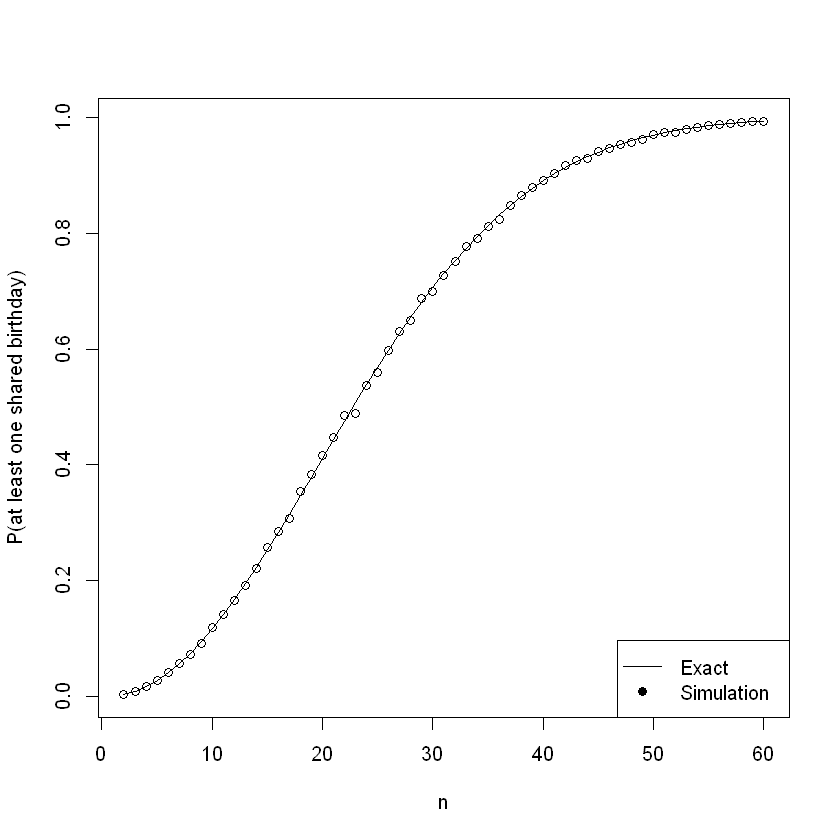

In [36]:
plot(n_vec, birthday_probs,
     type = "l",
     xlab = "n",
     ylab = "P(at least one shared birthday)")

points(n_vec, probs)

legend("bottomright",
       legend = c("Exact", "Simulation"),
       lty = c(1, NA),
       pch = c(NA, 16))

## Poker Mini-study

$$P(\text{one pair}) = \frac{13\binom{4}{2}\binom{12}{3}4^3}{\binom{52}{5}} = 0.422569$$

In [37]:
P_one_pair <- (13 * choose(4, 2) * choose(12, 3) * 4^3) / choose(52, 5)
P_one_pair

[1] 0.422569

$$P(\text{two pairs}) = \frac{\binom{13}{2}\binom{4}{2}^2(11)(4)}{\binom{52}{5}} = 0.047539$$

In [38]:
P_two_pairs <- (choose(13, 2) * choose(4, 2)^2 * 11 * 4) / choose(52, 5)
P_two_pairs

[1] 0.04753902

$$P(\text{three of a kind}) = \frac{13\binom{4}{3}\binom{12}{2}4^2}{\binom{52}{5}} = 0.021128$$

In [39]:
P_three_kind <- (13 * choose(4, 3) * choose(12, 2) * 4^2) / choose(52, 5)
P_three_kind

[1] 0.02112845

### Simulation

In [40]:
deck_ranks <- rep(1:13, each = 4)
simulate_hand <- function() {
    hand <- sample(deck_ranks, 5, replace = FALSE)
    counts <- sort(table(hand), decreasing = TRUE)
    if (identical(as.integer(counts), c(2L, 1L, 1L, 1L))) {
        return(1)
    }
    if (identical(as.integer(counts), c(2L, 2L, 1L))) {
        return(2)
    }
    if (identical(as.integer(counts), c(3L, 1L, 1L))) {
        return(3)
    }
    return(0)
}

sim_results <- replicate(200000, simulate_hand())

In [41]:
sim_one_pair <- mean(sim_results == 1)
sim_two_pairs <- mean(sim_results == 2)
sim_three_kind <- mean(sim_results == 3)

error_one_pair <- abs(sim_one_pair - P_one_pair) / P_one_pair
error_two_pairs <- abs(sim_two_pairs - P_two_pairs) / P_two_pairs
error_three_kind <- abs(sim_three_kind - P_three_kind) / P_three_kind

results <- data.frame(
    hand = c("one pair", "two pair", "three of a kind"),
    exact_prob = c(P_one_pair,  P_two_pairs, P_three_kind),
    sim_prob = c(sim_one_pair, sim_two_pairs, sim_three_kind),
    relative_error = c(error_one_pair, error_two_pairs, error_three_kind)
)
results

hand,exact_prob,sim_prob,relative_error
<chr>,<dbl>,<dbl>,<dbl>
one pair,0.42256903,0.419990,0.00610321
two pair,0.04753902,0.048115,0.01211604
three of a kind,0.02112845,0.021505,0.01782187



---
## Problem 5 — Matching (derangements) and “surprising” probabilities (12 pts)

Hat-check problem: \(N\) people each pick a random hat.

1. Compute $\(P(\text{no fixed points}) = D_N/N!\)$ using recurrence $\(D_N=(N-1)(D_{N-1}+D_{N-2})\)$, $\(D_0=1,D_1=0\)$. Compare for $\(N=5,\dots,12\) to \(e^{-1}\)$.
2. Monte Carlo for \(N=8\) and \(N=20\) (≥ 200,000 trials each). Report estimates and 95% CIs.
3. Briefly explain (Markdown) why the limit approaches \(e^{-1}\).


In [42]:
derangement <- numeric(13)
derangement[1] <- 1
derangement[2] <- 0
for (n in 2:12) {
    derangement[n + 1] <- (n - 1) * (derangement[n] + derangement[n - 1])
}

In [43]:
n_vec <- 6:13
D_vec <- derangement[n_vec]
D_vec

[1]        44       265      1854     14833    133496   1334961  14684570
[8] 176214841

In [44]:
D_prob <- D_vec / factorial(n_vec - 1)
D_prob

[1] 0.3666667 0.3680556 0.3678571 0.3678819 0.3678792 0.3678795 0.3678794
[8] 0.3678794

In [45]:
e_inv = exp(-1)
e_inv

[1] 0.3678794

In [46]:
derangements_sim <- function(N, trials = 200000) {
    successes <- 0
    for (i in 1:trials) {
        hats <- sample.int(N)
        if (all(hats != 1:N)) {
            successes <- successes + 1
        }
    }
    p_hat <- successes / trials
    ci <- p_hat + c(-1, 1) * 1.96 * sqrt(p_hat * (1 - p_hat) / trials)
    return(data.frame(n = n,
        trials = trials,
        prob = p_hat,
        ci_lower = ci[1],
        ci_upper = ci[2]
    ))
}
derangements_sim8  <- derangements_sim(8)
derangements_sim20 <- derangements_sim(20)

mc_results <- rbind(derangements_sim8, derangements_sim20)
mc_results

n,trials,prob,ci_lower,ci_upper
<int>,<dbl>,<dbl>,<dbl>,<dbl>
12,2e+05,0.370485,0.3683684,0.3726016
12,2e+05,0.369055,0.3669401,0.3711699


By the inclusion-exclusion formula. The number of derangements is

$$D_N = N!\sum_{k=0}^{N}\frac{(-1)^k}{k!}$$

divide by $N!$

$$\frac{D_N}{N!}=\sum_{k=0}^{N}\frac{(-1)^k}{k!}$$

and for $N\to\infty$, this is the Taylor series

$$\sum_{k=0}^{\infty}\frac{(-1)^k}{k!}=e^{-1}$$


---
## Problem 6 — Continuity of probability (monotone limits) (12 pts)

1. On \([0,1]\) with a single simulated uniform sample of size \(10^6\) (reuse it):  
   - Increasing events: $\(E_n = \{U \le 1 - 1/n\}\)$.  
   - Decreasing events: $\(F_n = \{U \ge 1/n\}\)$.  
   Empirically verify:  
   $\(\lim_{n\to\infty} P(E_n)=P(\bigcup_n E_n)\)$ and $\(\lim_{n\to\infty} P(F_n)=P(\bigcap_n F_n)\)$. Plot convergence.

2. Finite construction on a 2-die space: define \(E_n\) by thresholds on the sum (clipped to the maximum). Verify stabilization and equality of limits with exact counts.


In [47]:
N <- 10^6
U <- runif(N)
n_vec <- 1:100

P_En <- sapply(n_vec, function(n) mean(U <= 1 - 1/n))
P_Fn <- sapply(n_vec, function(n) mean(U >= 1/n))

results <- data.frame(
    n = n_vec,
    P_En = P_En,
    P_Fn = P_Fn
)
results$exact <- (1 - 1 / results)$n
results

n,P_En,P_Fn,exact
<int>,<dbl>,<dbl>,<dbl>
1,0.000000,0.000000,0.0000000
2,0.499834,0.500166,0.5000000
3,0.666924,0.667777,0.6666667
4,0.749922,0.750475,0.7500000
5,0.800001,0.800584,0.8000000
6,0.833343,0.834014,0.8333333
7,0.857229,0.857648,0.8571429
8,0.874892,0.875464,0.8750000
9,0.888833,0.889247,0.8888889


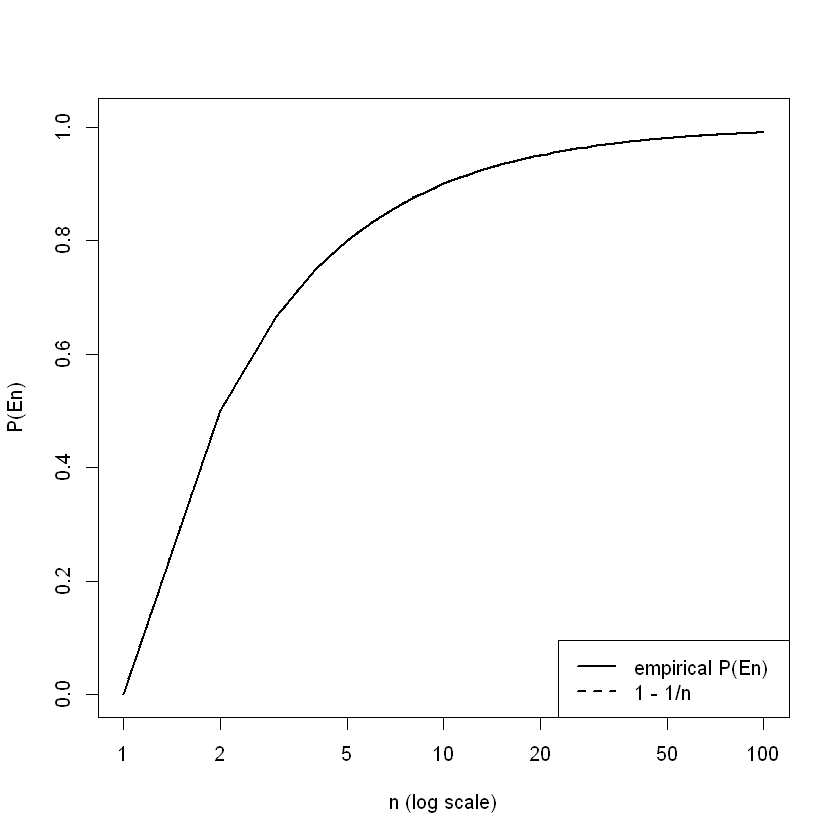

In [48]:
plot(results$n, results$P_En,
    type = "l",
    log = "x",
    lwd = 2,
    ylim = c(0, 1.01),
    xlab = "n (log scale)",
    ylab = "P(En)",
)

lines(results$n, results$exact, lty = 2, lwd = 2)

legend("bottomright",
    legend = c("empirical P(En)", "1 - 1/n"),
    lty = c(1, 2),
    lwd = c(2, 2)
)

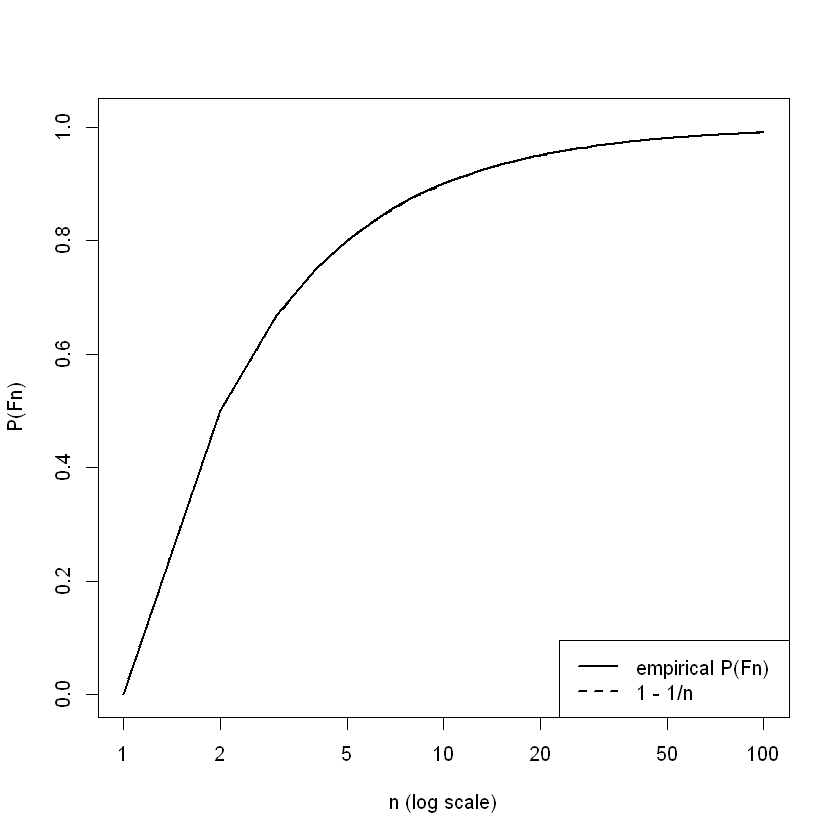

In [49]:
plot(results$n, results$P_Fn,
    type = "l",
    log = "x",
    lwd = 2,
    ylim = c(0, 1.01),
    xlab = "n (log scale)",
    ylab = "P(Fn)"
)

lines(results$n, results$exact, lty = 2, lwd = 2)

legend("bottomright",
    legend = c("empirical P(Fn)", "1 - 1/n"),
    lty = c(1, 2),
    lwd = c(2, 2)
)

### Finite construction on 2-die sample space

$S = {(i,j): i,j \in {1,\ldots,6}}$

$E_n = {(i,j): i+j \le \min(n,12)}$

The threshold is the maximum possible sum 12

In [50]:
S <- expand.grid(
    d1 = 1:6,
    d2 = 1:6
)
S$sum <- S$d1 + S$d2
head(S, 14)

,d1,d2,sum
,<int>,<int>,<int>
1,1,1,2
2,2,1,3
3,3,1,4
4,4,1,5
5,5,1,6
6,6,1,7
7,1,2,3
8,2,2,4
9,3,2,5


In [51]:
n_vec <- 1:15
counts_vec <- sapply(n_vec, function(n) { threshold <- min(n, 12); return(sum(S$sum <= threshold))})

results <- data.frame(
    n = n_vec,
    threshold = pmin(n_vec, 12),
    count = counts_vec,
    probability = counts_vec / 36
)
results

n,threshold,count,probability
<int>,<dbl>,<int>,<dbl>
1,1,0,0.00000000
2,2,1,0.02777778
3,3,3,0.08333333
4,4,6,0.16666667
5,5,10,0.27777778
6,6,15,0.41666667
7,7,21,0.58333333
8,8,26,0.72222222
9,9,30,0.83333333


$$E_{12}=E_{13}=E_{14}=S$$

The events are increasing and eventually contain the entire sample space

$$\lim_{n\to\infty}P(E_n)=P(E_{12})=1.0$$

$$\bigcup_{n=1}^{\infty}E_n=S$$

$$P\left(\bigcup_{n=1}^{\infty}E_n\right)=1.0$$

$$\lim_{n\to\infty}P(E_n) = P\left(\bigcup_{n=1}^{\infty}E_n\right)=1.0$$

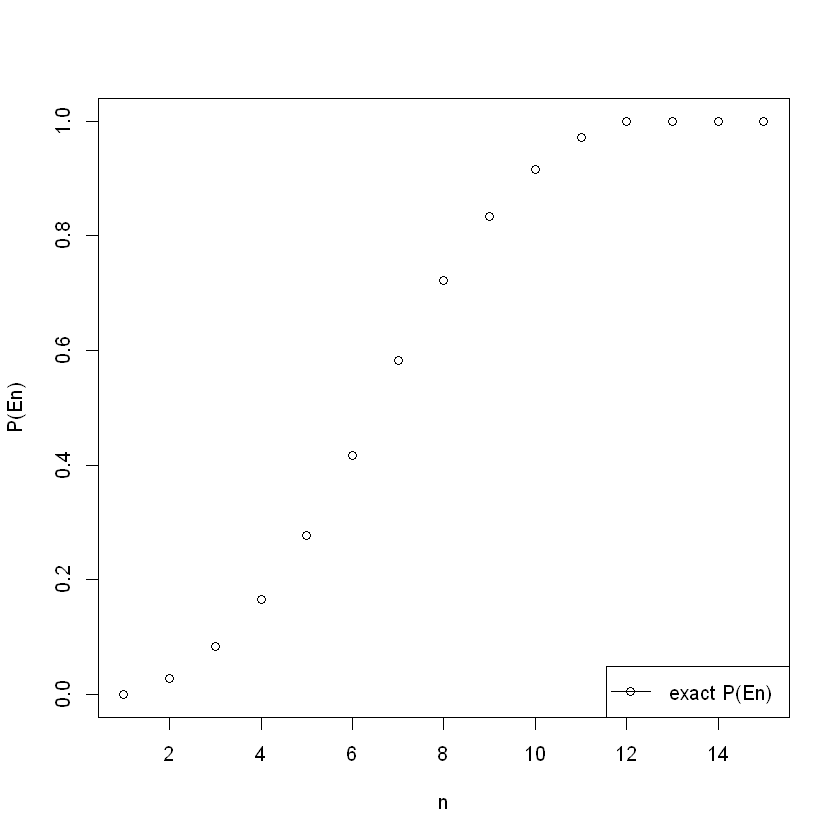

In [52]:
plot(results$n, results$probability,
    xlab = "n",
    ylab = "P(En)",
)

legend("bottomright",
    legend = c("exact P(En)"),
    lty = 1,
    pch = 1
)


---
## Problem 7 — From algebra to applications: craps **or** blackjack (14 pts)

Choose **one** option and perform both exact and Monte Carlo analysis.

**Option A: Craps.**  
1. Derive the exact probability the player wins (condition on the come-out roll; for point \(p\), compute \(P(\text{hit }p\text{ before }7)\)).  
2. Simulate ≥ 500,000 games; compare to exact value with absolute and relative errors.

**Option B: Blackjack opening hands.**  
1. Compute the exact probability that **neither** player nor dealer has a natural blackjack from a fresh single deck (player 2 cards, dealer 2 cards with hole card).  
2. Simulate ≥ 500,000 deals; compare and discuss convergence.


### Blackjack

$$\text{Let } E = {\text{player blackjack}}, F = {\text{dealer blackjack}}$$

$$P(\text{neither player nor dealer has a natural blackjack}) = P(E^c \cap F^c) = 1 - P(E \cup F) = 1 - (P(E) + P(F) - P(E \cap F))$$

$$P(E) = P(F) = \dfrac{4 \cdot 16}{\binom{52}{2}} = \dfrac{32}{663}$$

If the player has a natural blackjack, that removes one ace and one 10-value card leaving $3$ aces and $15$ 10-value cards remaining in $50$ cards.

$$P(F \mid E) = \dfrac{3 \cdot 15}{\binom{50}{2}}$$

$$P(E \cap F) = P(E)P(F \mid E)$$

$$P(E^c \cap F^c) = 1 - P(E) - P(F) + P(E)P(F \mid E)$$

In [53]:
PE <- (4 * 16) / choose(52, 2)
PF <- (4 * 16) / choose(52, 2)
PFgivenE <- (3 * 15) / choose(50, 2)
PEF <- PE * PFgivenE
Pneither <- 1 - PE - PF + PEF

PE
PF
PEF
Pneither

[1] 0.04826546

[1] 0.04826546

[1] 0.001773017

[1] 0.9052421

### Simulation

In [54]:
deck <- c(
  rep("A", 4),
  rep("T", 16),
  rep("O", 32)
)

is_blackjack <- function(hand) { 
    return(sum(hand == "A") == 1 && sum(hand == "T") == 1)
}

E <- logical(500000)
F <- logical(500000)
for (i in seq_len(500000)) {
    deal <- sample(deck, 4, replace = FALSE)
    player <- deal[1:2]
    dealer <- deal[3:4]
    E[i] <- is_blackjack(player)
    F[i] <- is_blackjack(dealer)
}

neither_vec <- !E & !F
prob_sim <- mean(neither_vec)
prob_sim

[1] 0.906248

In [55]:
Pneither; prob_sim

[1] 0.9052421

[1] 0.906248

In [56]:
mc_se <- sqrt(prob_sim * (1 - prob_sim) / 500000)
mc_ci <- prob_sim + c(-1, 1) * 1.96 * mc_se

abs(prob_sim - Pneither)
mc_se
mc_ci

[1] 0.001005903

[1] 0.0004122198

[1] 0.905440 0.907056

The simulation for n = 500,000 gives nearly the same probability of neither having a natural blackjack as inclusion-exclusion. As the number of simulations grows, the probability converges on the true exact value.

The absolute and standard error are both small and the result is nearly within the approximate 95% CI.


---
## Problem 8 — Probability as a measure of belief (subjective coherence) (14 pts)

1. Given $\((P(A),P(B),P(C),P(D))=(0.3,0.4,0.2,0.6)\)$ where $\(C=A\cap B\)$ and$\(D=A\cup B\)$, check coherence with axioms (bounds and $\(P(A\cup B)=P(A)+P(B)-P(AB)\))$. If incoherent, propose a minimally adjusted coherent set and justify (Markdown + small optimization if desired).
2. Implement a **consistency checker**: for inputs $\((p_A,p_B,p_{AB})\)$, compute implied $\(P(A\cup B)\)$ and flag violations (e.g., $\(p_{AB} > \min(p_A,p_B)\)$ or union not in \([0,1]\)). Run on at least 5 examples and summarize.


The bounds axiom states $$0\le P(A_k)\le1$$

Inclusion-exclusion states $$P(A\cup B)=P(A)+P(B)-P(A\cap B)$$

In [57]:
PA <- 0.3
PB <- 0.4
PAB <- 0.2
PAUB <- PA + PB - PAB
PAUB

[1] 0.5

$0.5 \neq 0.6$ so this example violates the axioms and is therefore incoherent

A valid example is $$P(A),P(B),P(C),P(D))=(0.3,0.4,0.2,0.5)$$

In [58]:
consistency_checker <- function(PA, PB, PAB) {
    PAUB <- PA + PB - PAB
    valid_PA <- PA >= 0 && PA <= 1
    valid_PB <- PB >= 0 && PB <= 1
    valid_PAB <- PAB >= 0 && PAB <= 1
    valid_upper_intersection <- PAB <= min(PA, PB)
    valid_lower_intersection <- PAB >= max(0, PA + PB - 1)
    valid_union <- PAUB >= 0 && PAUB <= 1
    
    consistent <- valid_PA && valid_PB && valid_PAB && valid_upper_intersection && valid_lower_intersection && valid_union
  
    return(data.frame(PAUB=PAUB, valid_PA=valid_PA, valid_PB=valid_PB, valid_PAB=valid_PAB,
        valid_upper_intersection=valid_upper_intersection, valid_lower_intersection=valid_lower_intersection,
        valid_union=valid_union, consistent=consistent))
}

In [59]:
consistency_checker(0.3, 0.4, 0.2)
consistency_checker(0.2, 0.5, 0.3)
consistency_checker(0.7, 0.6, 0.4)
consistency_checker(0.2, 0.5, 0.3)
consistency_checker(0.8, 0.7, 0.2)

PAUB,valid_PA,valid_PB,valid_PAB,valid_upper_intersection,valid_lower_intersection,valid_union,consistent
<dbl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>
0.5,TRUE,TRUE,TRUE,TRUE,TRUE,TRUE,TRUE


PAUB,valid_PA,valid_PB,valid_PAB,valid_upper_intersection,valid_lower_intersection,valid_union,consistent
<dbl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>
0.4,TRUE,TRUE,TRUE,FALSE,TRUE,TRUE,FALSE


PAUB,valid_PA,valid_PB,valid_PAB,valid_upper_intersection,valid_lower_intersection,valid_union,consistent
<dbl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>
0.9,TRUE,TRUE,TRUE,TRUE,TRUE,TRUE,TRUE


PAUB,valid_PA,valid_PB,valid_PAB,valid_upper_intersection,valid_lower_intersection,valid_union,consistent
<dbl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>
0.4,TRUE,TRUE,TRUE,FALSE,TRUE,TRUE,FALSE


PAUB,valid_PA,valid_PB,valid_PAB,valid_upper_intersection,valid_lower_intersection,valid_union,consistent
<dbl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>
1.3,TRUE,TRUE,TRUE,TRUE,FALSE,FALSE,FALSE



---
## Implementation & style requirements (graded, 12 pts)

- **Reproducibility (3 pts):** fixed seed; no interactive input; notebook runs top-to-bottom on “Restart & Run All”.
- **Numerical care (3 pts):** use exact combinatorics where appropriate; avoid under/overflow (consider log scale).
- **Validation (3 pts):** for exact results, include Monte Carlo cross-checks or unit tests on small cases.
- **Clarity (3 pts):** each problem starts with a Markdown plan, then R code, then a short interpretation.



---
## Submission checklist

- File name: `lastname_firstname_ch2_axioms.ipynb`
- Kernel: **R**
- Top cell includes `sessionInfo()` and `set.seed(631)`
- All figures inline; tables neatly formatted
- “Restart & Run All” completes without errors
